In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import rasterio
from shapely.geometry import box

In [2]:
def create_tile_extent_gpkg(
    input_directory,
    output_gpkg,
    layer_name,
    recursive=True
):
    """
    Erstellt ein GeoPackage mit einem Polygon pro GeoTIFF.

    Es werden nur die Raster-Metadaten gelesen.
    Die Rasterdaten selbst werden nicht geladen.
    """

    input_directory = Path(input_directory)
    output_gpkg = Path(output_gpkg)

    pattern = "**/*.tif" if recursive else "*.tif"
    raster_files = sorted(input_directory.glob(pattern))

    # Zusätzlich .tiff berücksichtigen
    pattern_tiff = "**/*.tiff" if recursive else "*.tiff"
    raster_files += sorted(input_directory.glob(pattern_tiff))

    raster_files = sorted(set(raster_files))

    print(f"Gefundene Raster: {len(raster_files)}")

    if not raster_files:
        raise FileNotFoundError(
            f"Keine GeoTIFFs gefunden in: {input_directory}"
        )

    records = []
    reference_crs = None

    for i, raster_file in enumerate(raster_files, start=1):
        try:
            with rasterio.open(raster_file) as src:
                if src.crs is None:
                    print(f"Übersprungen, kein CRS: {raster_file}")
                    continue

                if reference_crs is None:
                    reference_crs = src.crs

                bounds = src.bounds

                records.append({
                    "tile_id": raster_file.stem,
                    "filename": raster_file.name,
                    "filepath": str(raster_file),
                    "year": next(
                        (
                            int(part)
                            for part in raster_file.parts
                            if part.isdigit() and len(part) == 4
                        ),
                        None
                    ),
                    "width_px": src.width,
                    "height_px": src.height,
                    "bands": src.count,
                    "dtype": src.dtypes[0],
                    "res_x": src.res[0],
                    "res_y": src.res[1],
                    "crs": src.crs.to_string(),
                    "xmin": bounds.left,
                    "ymin": bounds.bottom,
                    "xmax": bounds.right,
                    "ymax": bounds.top,
                    "geometry": box(
                        bounds.left,
                        bounds.bottom,
                        bounds.right,
                        bounds.top
                    )
                })

        except Exception as error:
            print(f"Fehler bei {raster_file}: {error}")

        if i % 100 == 0:
            print(f"{i} / {len(raster_files)} verarbeitet")

    if not records:
        raise RuntimeError("Keine gültigen Raster konnten gelesen werden.")

    gdf = gpd.GeoDataFrame(
        records,
        geometry="geometry",
        crs=reference_crs
    )

    # Falls Raster unterschiedliche CRS besitzen, auf das Referenz-CRS bringen
    if gdf["crs"].nunique() > 1:
        print(
            "Warnung: Die Raster besitzen unterschiedliche CRS. "
            "Die Polygone sollten dann einzeln reprojiziert werden."
        )

    output_gpkg.parent.mkdir(parents=True, exist_ok=True)

    gdf.to_file(
        output_gpkg,
        layer=layer_name,
        driver="GPKG"
    )

    print(f"GeoPackage gespeichert: {output_gpkg}")
    print(f"Polygone: {len(gdf)}")

    return gdf

In [4]:
### Tessera
from pathlib import Path

import geopandas as gpd
import rasterio
from shapely.geometry import box


# ------------------------------------------------------------
# Einstellungen
# ------------------------------------------------------------

tessera_directory = Path(
    "/mnt/eo/UNIGIS/TESSERA_bavaria/"
    "2017/global_0.1_degree_tiff_all"
)

output_gpkg = Path(
    "/mnt/eo/UNIGIS/TESSERA_bavaria/"
    "tessera_tile_extents_epsg3035.gpkg"
)

layer_name = "tessera_tiles"
output_crs = "EPSG:3035"


# ------------------------------------------------------------
# TIFF-Dateien suchen
# Nur im angegebenen Ordner, nicht rekursiv
# ------------------------------------------------------------

raster_files = sorted(
    list(tessera_directory.glob("*.tif"))
    + list(tessera_directory.glob("*.tiff"))
)

print(f"Gefundene Raster: {len(raster_files)}")

if len(raster_files) == 0:
    raise FileNotFoundError(
        f"Keine TIFF-Dateien gefunden in:\n{tessera_directory}"
    )


# ------------------------------------------------------------
# Extents aus den Raster-Metadaten lesen
# ------------------------------------------------------------

records = []
skipped_files = []

for i, raster_file in enumerate(raster_files, start=1):

    try:
        with rasterio.open(raster_file) as src:

            if src.crs is None:
                skipped_files.append(
                    (str(raster_file), "Kein CRS vorhanden")
                )
                continue

            bounds = src.bounds

            tile_gdf = gpd.GeoDataFrame(
                [{
                    "tile_id": raster_file.stem,
                    "filename": raster_file.name,
                    "filepath": str(raster_file),
                    "source_crs": src.crs.to_string(),
                    "width_px": src.width,
                    "height_px": src.height,
                    "bands": src.count,
                    "dtype": src.dtypes[0],
                    "res_x": src.res[0],
                    "res_y": src.res[1],
                    "xmin_src": bounds.left,
                    "ymin_src": bounds.bottom,
                    "xmax_src": bounds.right,
                    "ymax_src": bounds.top,
                    "geometry": box(
                        bounds.left,
                        bounds.bottom,
                        bounds.right,
                        bounds.top
                    )
                }],
                geometry="geometry",
                crs=src.crs
            )

            # Jedes Tile einzeln nach EPSG:3035 transformieren.
            # Dadurch funktioniert der Code auch bei unterschiedlichen Quell-CRS.
            tile_gdf = tile_gdf.to_crs(output_crs)

            geom_bounds = tile_gdf.geometry.iloc[0].bounds

            record = tile_gdf.iloc[0].to_dict()

            record["xmin_3035"] = geom_bounds[0]
            record["ymin_3035"] = geom_bounds[1]
            record["xmax_3035"] = geom_bounds[2]
            record["ymax_3035"] = geom_bounds[3]

            records.append(record)

    except Exception as error:
        skipped_files.append(
            (str(raster_file), str(error))
        )

    if i % 100 == 0 or i == len(raster_files):
        print(
            f"{i} / {len(raster_files)} Raster verarbeitet; "
            f"{len(records)} gültig"
        )


# ------------------------------------------------------------
# Gemeinsames GeoDataFrame erstellen
# ------------------------------------------------------------

if len(records) == 0:
    raise RuntimeError(
        "Es konnten keine gültigen Raster-Extents erstellt werden."
    )

tessera_grid = gpd.GeoDataFrame(
    records,
    geometry="geometry",
    crs=output_crs
)

# Doppelte räumliche Tiles entfernen, falls vorhanden
tessera_grid = tessera_grid.drop_duplicates(
    subset=["tile_id"]
).reset_index(drop=True)

print(f"\nEindeutige Tiles: {len(tessera_grid)}")


# ------------------------------------------------------------
# GeoPackage schreiben
# ------------------------------------------------------------

output_gpkg.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Vorhandene Datei entfernen, damit keine alte Version erhalten bleibt
if output_gpkg.exists():
    output_gpkg.unlink()

tessera_grid.to_file(
    output_gpkg,
    layer=layer_name,
    driver="GPKG"
)

print(f"\nGeoPackage gespeichert unter:\n{output_gpkg}")
print(f"Layer: {layer_name}")
print(f"CRS: {tessera_grid.crs}")


# ------------------------------------------------------------
# Optional: übersprungene Dateien ausgeben
# ------------------------------------------------------------

if skipped_files:
    print(f"\nÜbersprungene Dateien: {len(skipped_files)}")

    for filepath, reason in skipped_files[:10]:
        print(f"- {filepath}")
        print(f"  Grund: {reason}")

    if len(skipped_files) > 10:
        print("Weitere übersprungene Dateien werden nicht angezeigt.")


# ------------------------------------------------------------
# Kurze Kontrolle im Notebook
# ------------------------------------------------------------

display(
    tessera_grid[
        [
            "tile_id",
            "filename",
            "source_crs",
            "xmin_3035",
            "ymin_3035",
            "xmax_3035",
            "ymax_3035",
            "geometry"
        ]
    ].head()
)

ax = tessera_grid.boundary.plot(
    figsize=(10, 10),
    linewidth=0.5
)

ax.set_title("TESSERA Tile-Extents")
ax.set_xlabel("Easting EPSG:3035 [m]")
ax.set_ylabel("Northing EPSG:3035 [m]")
ax.set_aspect("equal")

Gefundene Raster: 1700
100 / 1700 Raster verarbeitet; 100 gültig
200 / 1700 Raster verarbeitet; 200 gültig
300 / 1700 Raster verarbeitet; 300 gültig
400 / 1700 Raster verarbeitet; 400 gültig
500 / 1700 Raster verarbeitet; 500 gültig
600 / 1700 Raster verarbeitet; 600 gültig
700 / 1700 Raster verarbeitet; 700 gültig
800 / 1700 Raster verarbeitet; 800 gültig
900 / 1700 Raster verarbeitet; 900 gültig
1000 / 1700 Raster verarbeitet; 1000 gültig
1100 / 1700 Raster verarbeitet; 1100 gültig
1200 / 1700 Raster verarbeitet; 1200 gültig
1300 / 1700 Raster verarbeitet; 1300 gültig
1400 / 1700 Raster verarbeitet; 1400 gültig
1500 / 1700 Raster verarbeitet; 1500 gültig
1600 / 1700 Raster verarbeitet; 1600 gültig
1700 / 1700 Raster verarbeitet; 1700 gültig

Eindeutige Tiles: 1700


DataSourceError: Failed to start transaction

In [5]:
from pathlib import Path
import shutil

# Zunächst auf dem DSS-Dateisystem schreiben
temporary_gpkg = Path(
    "/mnt/dss_project/lmandl/"
    "tessera_tile_extents_epsg3035.gpkg"
)

# Anschließend hierhin kopieren
final_gpkg = Path(
    "/mnt/eo/UNIGIS/TESSERA_bavaria/"
    "tessera_tile_extents_epsg3035.gpkg"
)

layer_name = "tessera_tiles"

# Eventuell vorhandene temporäre Datei löschen
if temporary_gpkg.exists():
    temporary_gpkg.unlink()

# GeoPackage lokal schreiben
tessera_grid.to_file(
    temporary_gpkg,
    layer=layer_name,
    driver="GPKG",
    engine="pyogrio"
)

print(f"Lokal geschrieben: {temporary_gpkg}")

# Prüfen, ob das GeoPackage lesbar ist
test_grid = gpd.read_file(
    temporary_gpkg,
    layer=layer_name
)

print(f"Kontrolle: {len(test_grid)} Tiles gelesen")
print("CRS:", test_grid.crs)

# Vorhandene Zieldatei auf /mnt/eo entfernen
if final_gpkg.exists():
    final_gpkg.unlink()

# Fertige Datei auf das Netzlaufwerk kopieren
shutil.copy2(
    temporary_gpkg,
    final_gpkg
)

print(f"Nach /mnt/eo kopiert: {final_gpkg}")

Lokal geschrieben: /mnt/dss_project/lmandl/tessera_tile_extents_epsg3035.gpkg
Kontrolle: 1700 Tiles gelesen
CRS: EPSG:3035
Nach /mnt/eo kopiert: /mnt/eo/UNIGIS/TESSERA_bavaria/tessera_tile_extents_epsg3035.gpkg


Gefundene AlphaEarth-Raster: 360
100 / 360 verarbeitet; 100 gültig
200 / 360 verarbeitet; 200 gültig
300 / 360 verarbeitet; 300 gültig
360 / 360 verarbeitet; 360 gültig

AlphaEarth-Tiles: 360

Lokal geschrieben:
/mnt/dss_project/lmandl/alphaearth_tile_extents_epsg3035.gpkg
Kontrolle: 360 Tiles gelesen
CRS: EPSG:3035

Nach /mnt/eo kopiert:
/mnt/eo/UNIGIS/AlphaEarth_Bavaria/alphaearth_tile_extents_epsg3035.gpkg
Finale Datei enthält 360 Tiles
CRS: EPSG:3035


,tile_id,filename,source_crs,xmin_3035,ymin_3035,xmax_3035,ymax_3035,geometry
0,alphaearth_bayern_2017-0000000000-0000004096,alphaearth_bayern_2017-0000000000-0000004096.tif,EPSG:4326,4.274135e+06,3.009847e+06,4.300567e+06,3.050941e+06,"POLYGON ((4300407.038 3009846.509, 4300566.541..."
1,alphaearth_bayern_2017-0000000000-0000008192,alphaearth_bayern_2017-0000000000-0000008192.tif,EPSG:4326,4.300407e+06,3.009809e+06,4.326680e+06,3.050773e+06,"POLYGON ((4326679.913 3009809.104, 4326635.919..."
2,alphaearth_bayern_2017-0000000000-0000012288,alphaearth_bayern_2017-0000000000-0000012288.tif,EPSG:4326,4.326636e+06,3.009809e+06,4.352953e+06,3.050829e+06,"POLYGON ((4352952.623 3009903.496, 4352705.133..."
3,alphaearth_bayern_2017-0000000000-0000016384,alphaearth_bayern_2017-0000000000-0000016384.tif,EPSG:4326,4.352705e+06,3.009903e+06,4.379224e+06,3.051054e+06,"POLYGON ((4379224.406 3010129.685, 4378773.425..."
4,alphaearth_bayern_2017-0000000000-0000020480,alphaearth_bayern_2017-0000000000-0000020480.tif,EPSG:4326,4.378773e+06,3.010130e+06,4.405495e+06,3.051410e+06,"POLYGON ((4405494.503 3010487.668, 4404840.037..."


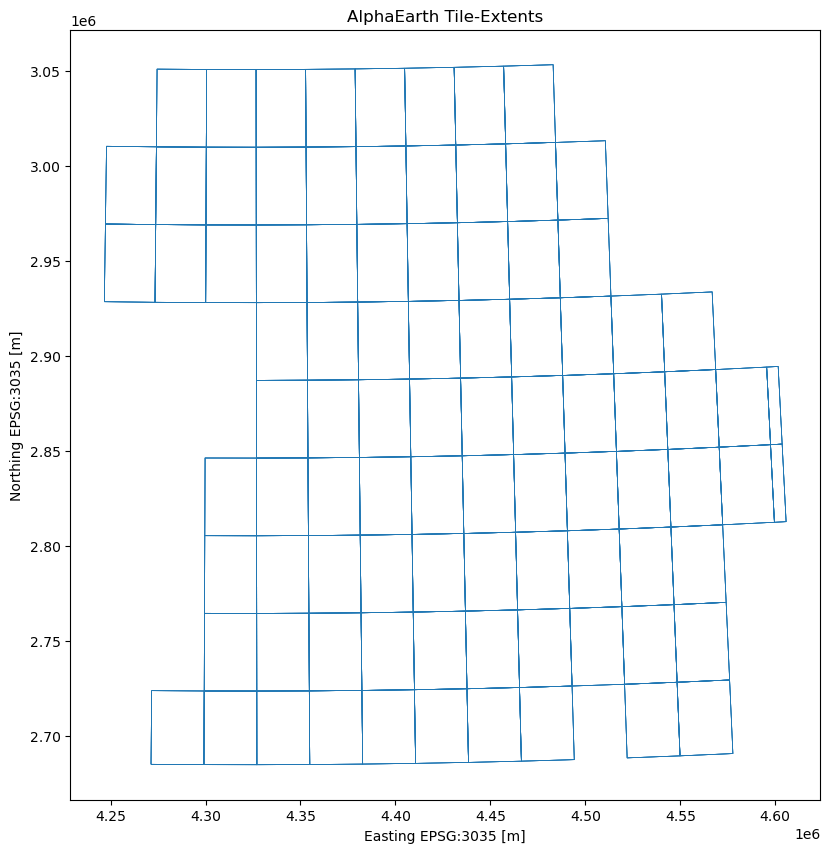

In [6]:
### AlphaEarth
from pathlib import Path
import shutil

import geopandas as gpd
import rasterio
from shapely.geometry import box


# ------------------------------------------------------------
# Einstellungen
# ------------------------------------------------------------

# Auf den Ordner mit den einzelnen AlphaEarth-Tiles setzen
alphaearth_directory = Path(
    "/mnt/eo/UNIGIS/AlphaEarth_Bavaria"
)

temporary_gpkg = Path(
    "/mnt/dss_project/lmandl/"
    "alphaearth_tile_extents_epsg3035.gpkg"
)

final_gpkg = Path(
    "/mnt/eo/UNIGIS/AlphaEarth_Bavaria/"
    "alphaearth_tile_extents_epsg3035.gpkg"
)

layer_name = "alphaearth_tiles"
output_crs = "EPSG:3035"

# True, falls die TIFFs in Unterordnern liegen
recursive = True


# ------------------------------------------------------------
# Rasterdateien suchen
# ------------------------------------------------------------

if recursive:
    raster_files = sorted(
        list(alphaearth_directory.rglob("*.tif"))
        + list(alphaearth_directory.rglob("*.tiff"))
    )
else:
    raster_files = sorted(
        list(alphaearth_directory.glob("*.tif"))
        + list(alphaearth_directory.glob("*.tiff"))
    )

# Bereits erzeugte Übersichtsraster gegebenenfalls ausschließen
raster_files = [
    path for path in raster_files
    if "tile_extents" not in path.name.lower()
]

print(f"Gefundene AlphaEarth-Raster: {len(raster_files)}")

if not raster_files:
    raise FileNotFoundError(
        f"Keine TIFF-Dateien gefunden in:\n{alphaearth_directory}"
    )


# ------------------------------------------------------------
# Extents aus den Raster-Metadaten lesen
# ------------------------------------------------------------

records = []
skipped_files = []

for i, raster_file in enumerate(raster_files, start=1):

    try:
        with rasterio.open(raster_file) as src:

            if src.crs is None:
                skipped_files.append(
                    (str(raster_file), "Kein CRS vorhanden")
                )
                continue

            bounds = src.bounds

            tile_gdf = gpd.GeoDataFrame(
                [{
                    "tile_id": raster_file.stem,
                    "filename": raster_file.name,
                    "filepath": str(raster_file),
                    "source_crs": src.crs.to_string(),
                    "width_px": src.width,
                    "height_px": src.height,
                    "bands": src.count,
                    "dtype": src.dtypes[0],
                    "res_x": src.res[0],
                    "res_y": src.res[1],
                    "xmin_src": bounds.left,
                    "ymin_src": bounds.bottom,
                    "xmax_src": bounds.right,
                    "ymax_src": bounds.top,
                    "geometry": box(
                        bounds.left,
                        bounds.bottom,
                        bounds.right,
                        bounds.top
                    )
                }],
                geometry="geometry",
                crs=src.crs
            )

            # Tile-Extent nach EPSG:3035 transformieren
            tile_gdf = tile_gdf.to_crs(output_crs)

            geom_bounds = tile_gdf.geometry.iloc[0].bounds
            record = tile_gdf.iloc[0].to_dict()

            record["xmin_3035"] = geom_bounds[0]
            record["ymin_3035"] = geom_bounds[1]
            record["xmax_3035"] = geom_bounds[2]
            record["ymax_3035"] = geom_bounds[3]

            records.append(record)

    except Exception as error:
        skipped_files.append(
            (str(raster_file), str(error))
        )

    if i % 100 == 0 or i == len(raster_files):
        print(
            f"{i} / {len(raster_files)} verarbeitet; "
            f"{len(records)} gültig"
        )


# ------------------------------------------------------------
# Gemeinsames GeoDataFrame erstellen
# ------------------------------------------------------------

if not records:
    raise RuntimeError(
        "Es konnten keine gültigen AlphaEarth-Extents erstellt werden."
    )

alphaearth_grid = gpd.GeoDataFrame(
    records,
    geometry="geometry",
    crs=output_crs
)

# Exakt doppelte Rastereinträge entfernen
alphaearth_grid = alphaearth_grid.drop_duplicates(
    subset=["filepath"]
).reset_index(drop=True)

print(f"\nAlphaEarth-Tiles: {len(alphaearth_grid)}")


# ------------------------------------------------------------
# Alte lokale GeoPackage-Dateien entfernen
# ------------------------------------------------------------

for suffix in ["", "-wal", "-shm", "-journal"]:
    path = Path(str(temporary_gpkg) + suffix)

    if path.exists():
        path.unlink()
        print("Gelöscht:", path)


# ------------------------------------------------------------
# GeoPackage auf DSS schreiben
# ------------------------------------------------------------

temporary_gpkg.parent.mkdir(
    parents=True,
    exist_ok=True
)

alphaearth_grid.to_file(
    temporary_gpkg,
    layer=layer_name,
    driver="GPKG",
    engine="pyogrio"
)

print(f"\nLokal geschrieben:\n{temporary_gpkg}")


# ------------------------------------------------------------
# Lokales GeoPackage kontrollieren
# ------------------------------------------------------------

test_grid = gpd.read_file(
    temporary_gpkg,
    layer=layer_name
)

print(f"Kontrolle: {len(test_grid)} Tiles gelesen")
print("CRS:", test_grid.crs)


# ------------------------------------------------------------
# Alte Dateien auf /mnt/eo entfernen
# ------------------------------------------------------------

final_gpkg.parent.mkdir(
    parents=True,
    exist_ok=True
)

for suffix in ["", "-wal", "-shm", "-journal"]:
    path = Path(str(final_gpkg) + suffix)

    if path.exists():
        path.unlink()
        print("Gelöscht:", path)


# ------------------------------------------------------------
# Fertiges GeoPackage nach /mnt/eo kopieren
# ------------------------------------------------------------

shutil.copy2(
    temporary_gpkg,
    final_gpkg
)

print(f"\nNach /mnt/eo kopiert:\n{final_gpkg}")


# ------------------------------------------------------------
# Kopierte Datei kontrollieren
# ------------------------------------------------------------

check_grid = gpd.read_file(
    final_gpkg,
    layer=layer_name
)

print(f"Finale Datei enthält {len(check_grid)} Tiles")
print("CRS:", check_grid.crs)


# ------------------------------------------------------------
# Vorschau
# ------------------------------------------------------------

display(
    check_grid[
        [
            "tile_id",
            "filename",
            "source_crs",
            "xmin_3035",
            "ymin_3035",
            "xmax_3035",
            "ymax_3035",
            "geometry"
        ]
    ].head()
)

ax = check_grid.boundary.plot(
    figsize=(10, 10),
    linewidth=0.5
)

ax.set_title("AlphaEarth Tile-Extents")
ax.set_xlabel("Easting EPSG:3035 [m]")
ax.set_ylabel("Northing EPSG:3035 [m]")
ax.set_aspect("equal")